In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

In [7]:
df3 = pd.read_csv("S:\DAtA SET\churn-bigml-20.csv")


# Clean column names
df3.columns = df3.columns.str.strip()

print(df3.columns)
df3.head()

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [8]:
le = LabelEncoder()

for col in df3.select_dtypes(include='object').columns:
    df3[col] = le.fit_transform(df3[col])

In [9]:
X = df3.drop("Churn", axis=1)
y = df3["Churn"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.917910447761194
              precision    recall  f1-score   support

       False       0.94      0.97      0.95       119
        True       0.70      0.47      0.56        15

    accuracy                           0.92       134
   macro avg       0.82      0.72      0.76       134
weighted avg       0.91      0.92      0.91       134



In [13]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.9029850746268657
              precision    recall  f1-score   support

       False       0.94      0.95      0.95       119
        True       0.57      0.53      0.55        15

    accuracy                           0.90       134
   macro avg       0.76      0.74      0.75       134
weighted avg       0.90      0.90      0.90       134



In [14]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9701492537313433
              precision    recall  f1-score   support

       False       0.98      0.99      0.98       119
        True       0.92      0.80      0.86        15

    accuracy                           0.97       134
   macro avg       0.95      0.90      0.92       134
weighted avg       0.97      0.97      0.97       134



In [15]:
params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 50}


In [16]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Final Model")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Final Model
Accuracy: 0.9477611940298507
              precision    recall  f1-score   support

       False       0.95      0.99      0.97       119
        True       0.90      0.60      0.72        15

    accuracy                           0.95       134
   macro avg       0.93      0.80      0.85       134
weighted avg       0.95      0.95      0.94       134



✅ Using column: Text


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sanke\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sanke\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                     clean_text sentiment_label
0         enjoy beauti day park        Positive
1          traffic terribl morn         Neutral
2           finish amaz workout         Neutral
3   excit upcom weekend getaway         Neutral
4  tri new recip dinner tonight        Positive


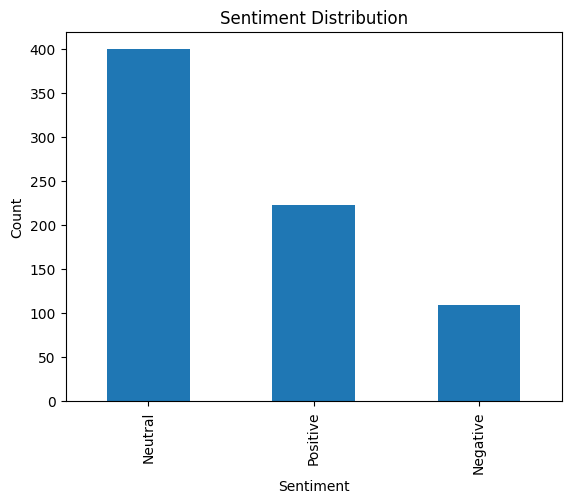

In [17]:
# ==============================
# NLP 
# ==============================
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("S:\DAtA SET\sentiment.csv")

# -------------------------------
# STEP 1: Find text column safely
# -------------------------------
text_cols = df.select_dtypes(include='object').columns

if len(text_cols) == 0:
    print("❌ No text column found → NLP skipped")
else:
    text_col = text_cols[0]
    print("✅ Using column:", text_col)

    # -------------------------------
    # STEP 2: Import NLP libraries
    # -------------------------------
    import nltk
    from nltk.tokenize import word_tokenize
    from nltk.corpus import stopwords
    from nltk.stem import PorterStemmer
    from textblob import TextBlob

    nltk.download('punkt')
    nltk.download('stopwords')

    stemmer = PorterStemmer()
    stop_words = set(stopwords.words('english'))

    # -------------------------------
    # STEP 3: Preprocessing
    # -------------------------------
    def preprocess(text):
        words = word_tokenize(str(text).lower())
        words = [stemmer.stem(w) for w in words if w.isalnum() and w not in stop_words]
        return " ".join(words)

    df['clean_text'] = df[text_col].apply(preprocess)

    # -------------------------------
    # STEP 4: Sentiment Analysis
    # -------------------------------
    df['sentiment'] = df['clean_text'].apply(lambda x: TextBlob(x).sentiment.polarity)

    df['sentiment_label'] = df['sentiment'].apply(
        lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral')
    )

    print(df[['clean_text', 'sentiment_label']].head())

    # -------------------------------
    # STEP 5: Visualization
    # -------------------------------
    df['sentiment_label'].value_counts().plot(kind='bar')
    plt.title("Sentiment Distribution")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()